## Fake News Detection Using Machine Learning


*Project Overview*

This project develops a simple Fake News Detection system using Machine Learning.

The system takes the text of a news article as input and predicts whether the article is:

Fake News

Real News

The project uses:

Python

Pandas

Scikit-learn

TF-IDF Vectorization

Logistic Regression

Streamlit

## Import Required Libraries

In this section, we import the libraries required for data preprocessing,
visualization, machine learning, evaluation, and model saving.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import joblib

## Load Dataset

The dataset contains two files:

- Fake.csv - Fake news articles
- True.csv - Real news articles

We load both datasets using Pandas.

In [2]:
fake = pd.read_csv("Fake.csv")
true = pd.read_csv("True.csv")

print("Fake News Shape:", fake.shape)
print("Real News Shape:", true.shape)

Fake News Shape: (23481, 4)
Real News Shape: (21417, 4)


In [3]:
fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [4]:
true.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


## Add Target Labels

Machine Learning requires a target variable.

We assign:

- 0 = Fake News
- 1 = Real News

In [5]:
fake["label"] = 0
true["label"] = 1

## Combine Fake and Real News

The Fake and Real datasets are combined into a single dataset.

In [6]:
data = pd.concat([fake, true], ignore_index=True)

print("Total Records:", len(data))

Total Records: 44898


In [7]:
print(data.columns)

Index(['title', 'text', 'subject', 'date', 'label'], dtype='object')


## Check Missing Values

Missing values can cause problems during model training, so we check
and remove records where the news text is missing.

In [8]:
print(data.isnull().sum())

title      0
text       0
subject    0
date       0
label      0
dtype: int64


In [9]:
data = data.dropna(subset=["text"])

print("Dataset Shape:", data.shape)

Dataset Shape: (44898, 5)


## Remove Duplicate Records

Duplicate news articles can affect the model evaluation.
Therefore, duplicate records are removed.

In [10]:
print("Duplicate Records:", data.duplicated().sum())

Duplicate Records: 209


In [11]:
data = data.drop_duplicates()

print("Dataset Shape After Removing Duplicates:", data.shape)

Dataset Shape After Removing Duplicates: (44689, 5)


## Select Required Columns

For this simple project, only the news text and target label are required.

In [12]:
data = data[["text", "label"]]

data.head()

,text,label
0,Donald Trump just couldn t wish all Americans ...,0
1,House Intelligence Committee Chairman Devin Nu...,0
2,"On Friday, it was revealed that former Milwauk...",0
3,"On Christmas day, Donald Trump announced that ...",0
4,Pope Francis used his annual Christmas Day mes...,0


## Exploratory Data Analysis

We analyze the distribution of Fake and Real news articles.

In [13]:
print(data["label"].value_counts())

label
0    23478
1    21211
Name: count, dtype: int64


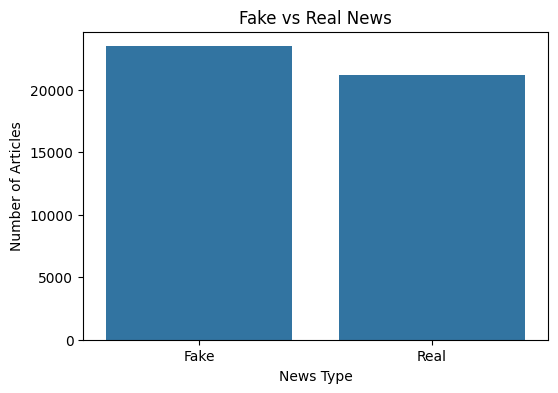

In [14]:
plt.figure(figsize=(6, 4))

sns.countplot(x="label", data=data)

plt.title("Fake vs Real News")
plt.xlabel("News Type")
plt.ylabel("Number of Articles")

plt.xticks([0, 1], ["Fake", "Real"])

plt.show()

## Prepare Features and Target

The `text` column is used as the input feature.

The `label` column is used as the target variable.

In [15]:
X = data["text"]
y = data["label"]

## Train-Test Split

The dataset is divided into:

- 80% training data
- 20% testing data

The training data is used to train the model, while the testing data
is used to evaluate its performance.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 35751
Testing Samples: 8938


## TF-IDF Text Vectorization

Machine Learning algorithms cannot directly understand text.

TF-IDF (Term Frequency-Inverse Document Frequency) converts text into
numerical features that can be processed by the Machine Learning model.

In [17]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_df=0.7
)

X_train_tfidf = vectorizer.fit_transform(X_train)

X_test_tfidf = vectorizer.transform(X_test)

print("Training TF-IDF Shape:", X_train_tfidf.shape)
print("Testing TF-IDF Shape:", X_test_tfidf.shape)

Training TF-IDF Shape: (35751, 110824)
Testing TF-IDF Shape: (8938, 110824)


## Train Machine Learning Model

Logistic Regression is used as the classification algorithm.

It is a simple and commonly used algorithm for text classification.

In [18]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train_tfidf, y_train)

print("Model Training Completed!")

Model Training Completed!


## Model Prediction

The trained model is used to predict the labels of the testing dataset.

In [19]:
y_pred = model.predict(X_test_tfidf)

print(y_pred[:10])

[1 1 1 0 1 0 0 0 0 1]


## Model Evaluation

Accuracy is calculated to measure how many test samples were classified
correctly.

In [20]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100)

Accuracy: 0.98489594987693
Accuracy Percentage: 98.489594987693


In [21]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Fake", "Real"]
    )
)

              precision    recall  f1-score   support

        Fake       0.99      0.98      0.99      4696
        Real       0.98      0.99      0.98      4242

    accuracy                           0.98      8938
   macro avg       0.98      0.98      0.98      8938
weighted avg       0.98      0.98      0.98      8938



## Confusion Matrix

A confusion matrix shows the number of correct and incorrect predictions
made by the model.

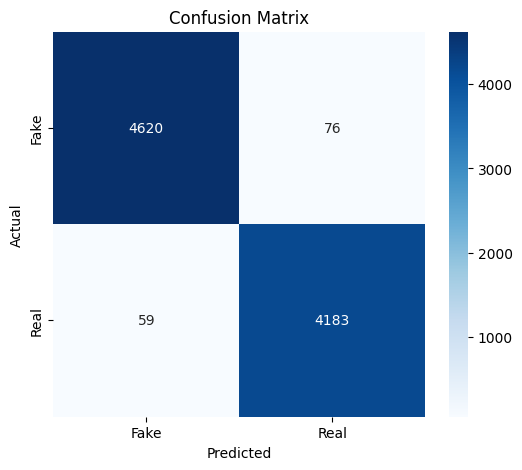

In [22]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fake", "Real"],
    yticklabels=["Fake", "Real"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

## Create Prediction Function

This function accepts a news article as input and returns the predicted
classification.

In [23]:
def predict_news(news_text):

    news_tfidf = vectorizer.transform([news_text])

    prediction = model.predict(news_tfidf)

    if prediction[0] == 0:
        return "FAKE NEWS"
    else:
        return "REAL NEWS"

In [24]:
news = """
Scientists announced a new discovery after conducting several years
of research.
"""

result = predict_news(news)

print("Prediction:", result)

Prediction: FAKE NEWS


## Save Trained Model

The trained model and TF-IDF vectorizer are saved using Joblib.

They will later be loaded by the Streamlit application.

In [25]:
joblib.dump(model, "fake_news_model.pkl")

joblib.dump(
    vectorizer,
    "tfidf_vectorizer.pkl"
)

print("Model saved successfully!")

Model saved successfully!
